# Packages

In [31]:
import os, json, io
import labelbox as lb
import numpy as np
from PIL import Image
import cv2
from datetime import datetime
from tqdm.auto import tqdm
from export_labelbox import make_http_session, download_image
import matplotlib.pyplot as plt

# Define COCO Data

In [32]:
coco_data = {}
coco_data = {
    "info": {
        "description": "Mourin Cell Detection Dataset",
        "url": "hhttps://www.kaggle.com/datasets/thanglexuan/cell-detection/data",
        "version": "3.0",
        "year": 2025,
        "contributor": "Research Team - Luan Vu, Lan Anh, Thang Le",
        "date_created": datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    },
    
    "licenses": [
        {
            "id": 1,
            "name": "Research Use Only",
            "url": "following the license terms of the dataset"
        }
    ],
    
    # CATEGORIES 
    "categories": [
        {
            "id": 1,
            "name": "Marcophage/Monocyte",
            "supercategory": "mourin_cells"
        },
        {
            "id": 2,
            "name": "Neutrophil", 
            "supercategory": "mourin_cells"
        },
        {
            "id": 3,
            "name": "Eosinophil",
            "supercategory": "mourin_cells"
        },
        {
            "id": 4,
            "name": "Lymphocyte",
            "supercategory": "mourin_cells"
        },
        {
            "id": 5,
            "name": "Unknown cell/Debris",
            "supercategory": "mourin_cells"
        }
    ],
    
    # Empty lists for images and annotations - will be populated dynamically 
    "images": [],
    "annotations": []
}

# Get data from labelbox

In [14]:
root_dir = "D:\OneDrive\WORKING\Projects\CellDetection\Code\Mourincells"
data_dir = os.path.join(root_dir, "data")
labelbox_dir = os.path.join(root_dir, "labelbox") 
token_path = os.path.join(labelbox_dir, "token.json")
labelbox_path = os.path.join(labelbox_dir, "labelbox.json")

with open(token_path,'r') as f:
    token_data = json.load(f)
    API_KEY = token_data['api_key']
    PROJECT_ID = token_data['project_id']

# Labelbox client
client = lb.Client(api_key=API_KEY)

# Project
project = client.get_project(PROJECT_ID)

# defind export parameters of labelbox
export_params = {
    "attachments": True,
    "metadata_fields": True,
    "data_row_details": True,
    "project_details": False,
    "label_details": True,
    "performance_details": False,
    "interpolated_frames": True,
    "embeddings": False,
}

filters = {
}

# Export
export_task = project.export_v2(params=export_params, filters=filters)
export_task.wait_till_done()
if export_task.errors:
    print(export_task.errors)
data = export_task.result

C:\Users\admin\AppData\Local\Temp\ipykernel_22604\534032810.py:34: DeprecationWarning: The method export_v2 for Project is deprecated and will be removed in the next major release. Use the export method instead.
  export_task = project.export_v2(params=export_params, filters=filters)


# MAIN PART

In [15]:
IMAGE_DIR = os.path.join(data_dir, "images")
MASK_DIR = os.path.join(data_dir, "masks")
ANNOTATION_DIR = os.path.join(data_dir, "annotations")

# Create annotations directory if it doesn't exist
os.makedirs(ANNOTATION_DIR, exist_ok=True)

## Convert functions

In [6]:
from random import randint
ROW_INDEX = randint(0, len(data) - 1)
item = data[ROW_INDEX]
media = item["media_attributes"]
W, H = media["width"], media["height"]
row   = item["data_row"]
ext_id = row.get("external_id", f"row_{ROW_INDEX}.png")
base   = os.path.splitext(ext_id)[0]
img_url = row["row_data"]

In [7]:
example = data[0]
mask = example['projects'][PROJECT_ID]['labels']
mask_url = mask[0]['annotations']['objects']
len(mask_url)
for i in range(len(mask_url)):
    print(mask_url[i]['mask']['url'])
cell_type = mask_url[0]['name']
cell_type
img_name = data[0]['data_row']['external_id']
img_name

# img_path = os.path.join(IMAGE_DIR, img_name)
# mask_path = os.path.join(MASK_DIR, img_name)

img_url = example['data_row']['row_data']
# # load image
session = make_http_session()
img = download_image(img_url, session=session)
batch_mask = download_image(mask_url[0]['mask']['url'],headers=client.headers, session=session, timeout=10)
# img_url
type(img)
type(batch_mask)

https://api.labelbox.com/api/v1/projects/clvggmnsa001907zf5j51g5sv/annotations/clvlgebpb0003356pr57yxkqe/index/1/mask
https://api.labelbox.com/api/v1/projects/clvggmnsa001907zf5j51g5sv/annotations/clvlgelws000c356p8m4gjnwr/index/1/mask
https://api.labelbox.com/api/v1/projects/clvggmnsa001907zf5j51g5sv/annotations/clvlgeos2000h356pf478k5tm/index/1/mask
https://api.labelbox.com/api/v1/projects/clvggmnsa001907zf5j51g5sv/annotations/clvlgernl000m356pgwiapeq4/index/1/mask
https://api.labelbox.com/api/v1/projects/clvggmnsa001907zf5j51g5sv/annotations/clvlgf0qi000z356p360mhu77/index/1/mask
https://api.labelbox.com/api/v1/projects/clvggmnsa001907zf5j51g5sv/annotations/clvlgffva001d356pof62skrs/index/1/mask
https://api.labelbox.com/api/v1/projects/clvggmnsa001907zf5j51g5sv/annotations/clvlgfj85001i356phapp1r7k/index/1/mask
https://api.labelbox.com/api/v1/projects/clvggmnsa001907zf5j51g5sv/annotations/clvlgfm43001n356p7yilug4f/index/1/mask
https://api.labelbox.com/api/v1/projects/clvggmnsa001907

PIL.PngImagePlugin.PngImageFile

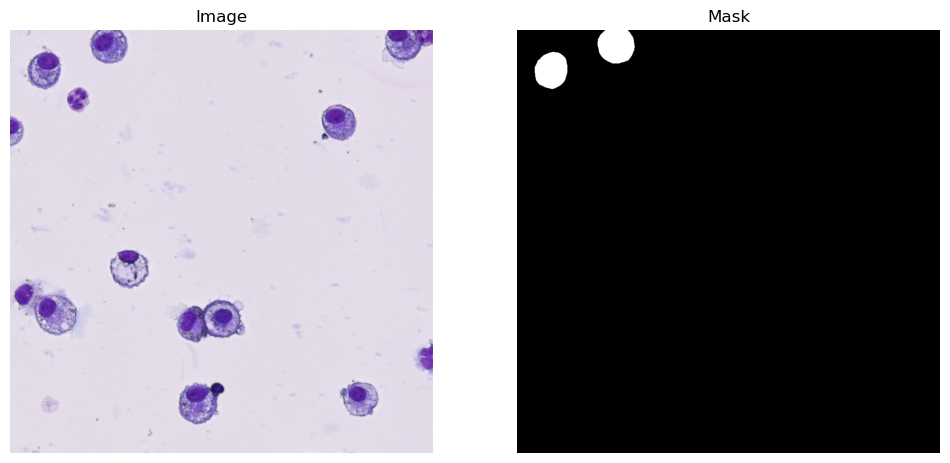

In [99]:
# plot image and batch_mask
plt.subplots(1,2, figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title("Image")
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(batch_mask, cmap='gray')
plt.title("Mask")   
plt.axis('off')
plt.show()

In [100]:
# batch_mask is PIL IMAGE has value 0 and 255 -> grayscale
# convert to numpy array
batch_mask = np.array(batch_mask)  # Convert PIL image to numpy array
print(f"batch_mask.shape: {batch_mask.shape}")
# convert to cv2 format
# Tìm contours và bounding boxes
contours, _ = cv2.findContours(batch_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

bounding_boxes = []
for contour in contours:
    x, y, w, h = cv2.boundingRect(contour)
    bounding_boxes.append((x, y, x+w, y+h))  # (x1, y1, x2, y2)

print(f"Tìm thấy {len(bounding_boxes)} bounding boxes: {bounding_boxes}")

batch_mask.shape: (1024, 1024)
Tìm thấy 2 bounding boxes: [(43, 53, 122, 143), (195, 0, 285, 81)]


In [102]:
from PIL import Image, ImageDraw

draw = ImageDraw.Draw(img)

# Vẽ các bounding box
for i, (x1, y1, x2, y2) in enumerate(bounding_boxes):
    draw.rectangle([x1, y1, x2, y2], outline='red', width=2)
    draw.text((x1, y1-100), f'Object {i+1}', fill='red')

img.show()

In [16]:
def check_catagories(mask_name, coco_data):
    """
    Check if categories are defined in the coco data
    If not, define categories with id 1 and name "cell"
    """
    # take categories from coco_data
    categories = coco_data.get('categories', [])
    
    # Check if the mask_name exists in categories
    for category in categories:
        if category['name'] == mask_name:
            return category['id']

In [ ]:
# image_name = example['data_row']['external_id']
# image_url = example['data_row']['row_data']
# image_width = example['media_attributes']['width']
# image_height = example['media_attributes']['height']

# print(f"Image Name: {image_name}")
# print(f"Image URL: {image_url}")
# print(f"Image Width: {image_width}")
# print(f"Image Height: {image_height}")


# masks_data = example['projects'][PROJECT_ID]['labels'][0]['annotations']['objects']
# mask_url = masks_data[0]['mask']['url']
# mask_name = masks_data[0]['name']
# catagory_id = check_catagories(mask_name, coco_data)
# print(f"all masks in an example is {len(masks_data)}")
# print(f"Mask URL: {mask_url}")
# print(f"Mask Name: {mask_name}")
# print(f"Mask ID: {catagory_id}")


Image Name: P01_9_25.png
Image URL: https://storage.labelbox.com/clpyug3to102w07zf3bjoa9nx%2F1cbdb5ab-6532-0ea9-2b1e-b075ebd5cc74-P01_9_25.png?Expires=1755769151573&KeyName=labelbox-assets-key-3&Signature=UUKrg78-FWVCwygRP-gq6mVY-HU
Image Width: 1024
Image Height: 1024
all masks in an example is 15
Mask URL: https://api.labelbox.com/api/v1/projects/clvggmnsa001907zf5j51g5sv/annotations/clvlgebpb0003356pr57yxkqe/index/1/mask
Mask Name: Marcophage/Monocyte
Catagory ID: 1


In [ ]:
"""
    this function will convert masks from labelbox to bounding boxes in COCO format
    mask is an image with value 0 and 255, has shape (H, W)
    it will do the following steps:
    # function steps
    # list of step we need to do
    # create a loop with each image in data, we will download image 
    # with each image, we will have masks, 
    # then we will loop through each mask and find contours
    # when we have contours we will find bounding boxes
    # when we have bounding boxes, we will caculate area of bounding boxes
    # then we will create coco data with images, annotations, categories
    # finally we will save coco data to json file
"""
session = make_http_session()

for idx, item in enumerate(tqdm(data, total=len(data), desc="Converting Images", unit="img"),start=1):
    # idx += 1
    # get image data
    image_name = item['data_row']['external_id']
    image_url = item['data_row']['row_data']
    base_image = download_image(image_url, session=session)
    assert base_image is not None, f"Failed to download image from {image_url}"
    assert isinstance(base_image, Image.Image), f"Downloaded image is not a PIL Image: {type(base_image)}"

    # get image size from media attributes
    W = item['media_attributes']['width']
    H = item['media_attributes']['height']
    assert W > 0 and H > 0, f"Invalid image dimensions: {W}x{H}"

    # add size of image to coco data
    coco_data['images'].append({
        "id": idx,
        "width": W,
        "height": H,
        "image_name": image_name,
        "image_url": image_url, 
    })
    masks_data = item['projects'][PROJECT_ID]['labels'][0]['annotations']['objects']

    for mask_idx, mask in enumerate(tqdm(masks_data, total=len(masks_data), desc=f"Processing masks for {image_name}", unit="mask"),start=1):
        mask_url = mask['mask']['url']
        mask_name = mask['name']
        category_id = check_catagories(mask_name, coco_data)
        assert category_id is not None, f"Mask ID is None for {mask_name} in {image_name}"
        assert mask_url is not None, f"Mask URL is None for {mask_name} in {image_name}"
        
        # download mask
        mask_image = download_image(mask_url, headers=client.headers, session=session)
        assert isinstance(mask_image, Image.Image), f"Downloaded mask is not a PIL Image: {type(mask_image)}"
        
        # convert to numpy array
        mask_array = np.array(mask_image)
        assert mask_array.ndim == 2, f"Mask array should be 2D, got {mask_array.ndim}D"
        
        # find contours and bounding boxes
        contours, _ = cv2.findContours(mask_array, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
         
        for idx_contour, contour in enumerate(contours):
            x, y, w, h = cv2.boundingRect(contour)
            bbox = [x, y, x + w, y + h]
            area = w * h
            annotation = {
                "id": mask_idx + 1,  # Unique ID for each annotation
                "image_id": idx,
                "mask_url": mask_url,  # URL of the mask image
                "category_id": category_id,  # Assuming single category for now
                "bbox": bbox,
                "area": area,
                "iscrowd": 0,
            }
            coco_data['annotations'].append(annotation)
    # Save the coco_data to a JSON file
    file_name = image_name.split('.')[0]
    annotation_file = os.path.join(ANNOTATION_DIR, f"{file_name}.json")
    with open(annotation_file, 'w') as f:
        json.dump(coco_data, f, indent=4)



Converting Images:   0%|          | 0/2 [00:00<?, ?img/s]

Processing masks for P01_9_25.png:   0%|          | 0/15 [00:00<?, ?mask/s]

Processing masks for P01_10_16.png:   0%|          | 0/26 [00:00<?, ?mask/s]

In [34]:
coco_data

{'info': {'description': 'Mourin Cell Detection Dataset',
  'url': 'hhttps://www.kaggle.com/datasets/thanglexuan/cell-detection/data',
  'version': '3.0',
  'year': 2025,
  'contributor': 'Research Team - Luan Vu, Lan Anh, Thang Le',
  'date_created': '2025-08-20 14:30:12'},
 'licenses': [{'id': 1,
   'name': 'Research Use Only',
   'url': 'following the license terms of the dataset'}],
 'categories': [{'id': 1,
   'name': 'Marcophage/Monocyte',
   'supercategory': 'mourin_cells'},
  {'id': 2, 'name': 'Neutrophil', 'supercategory': 'mourin_cells'},
  {'id': 3, 'name': 'Eosinophil', 'supercategory': 'mourin_cells'},
  {'id': 4, 'name': 'Lymphocyte', 'supercategory': 'mourin_cells'},
  {'id': 5, 'name': 'Unknown cell/Debris', 'supercategory': 'mourin_cells'}],
 'images': [{'id': 1,
   'width': 1024,
   'height': 1024,
   'image_name': 'P01_9_25.png',
   'image_url': 'https://storage.labelbox.com/clpyug3to102w07zf3bjoa9nx%2F1cbdb5ab-6532-0ea9-2b1e-b075ebd5cc74-P01_9_25.png?Expires=1755781

In [38]:
def category_id_to_name(category_id, coco_data):
    """
    Convert category ID to category name
    """
    categories = coco_data.get('categories', [])
    for category in categories:
        if category['id'] == category_id:
            return category['name']
    return None

In [ ]:
import PIL.ImageDraw as ImageDraw
# Get all information in coco_data and draw image with bboxes
# get 3 images from coco_data
session = make_http_session()
for image in coco_data['images']:
    image_id = image['id']
    image_name = image['image_name']
    image_url = image['image_url']
 
    # Download the image
    base_image = download_image(image_url, session=session)
    assert base_image is not None, f"Failed to download image from {image_url}"
    
    # Create a draw object
    draw = ImageDraw.Draw(base_image)
    
    # Draw bounding boxes
    for annotation in coco_data['annotations']:
        if annotation['image_id'] == image_id:
            category_name = category_id_to_name(annotation['category_id'], coco_data)
            bbox = annotation['bbox']
            draw.rectangle(bbox, outline='red', width=2)
            draw.text((bbox[0], bbox[3]), f"{category_name} ID: {annotation['id']}", fill='red')
    
    # Show the image with bounding boxes
    base_image.show()